<h2 style="color: #00fceb;">Non-Performing Loan Analysis / Анализ NPL: FinTech-кредитор DigitalLoan</h2>

<p style="color: #00fc7e; font-size: 18px;">
Synthetic data analysis reproducing the handwritten notes for the non-performing loan task. The notebook calculates the NPL ratio per quarter and the coverage ratio, then verifies the figures against the handwritten notes (4% to 9%).
</p>

<p style="color: #00fc7e; font-size: 18px;">
Анализ синтетических данных, воспроизводящий рукописный конспект по задаче о доле проблемных кредитов в портфеле. Ноутбук рассчитывает NPL Ratio (долю проблемных кредитов в портфеле) и Coverage Ratio (покрытие проблемных кредитов резервами) по кварталам, а затем сверяет результат с рукописным конспектом (с 4% до 9%).
</p>

<h3 style="color: #00fceb;">Implementation / Решение проблем</h3>
<ol>
    <li style="color: #00fc7e; font-size: 18px;">Access npl.py through the built-in sys module / Получить доступ к файлу npl.py через встроенный модуль sys</li>
    <li style="color: #00fc7e; font-size: 18px;">Import connect_to_db to connect to the local database and read the synthetic NPL data / Импортировать функцию <code>connect_to_db</code> для подключения к локальной базе и чтения синтетических данных по проблемным кредитам</li>
</ol>

In [62]:
import sys
sys.path.append("../3_python/")
import matplotlib.pyplot as plt

from npl import connect_to_db
import pandas as pd

conn = connect_to_db()

Connected to the database


<ol>
    <li style="color: #00fc7e; font-size: 18px;">Run the CTE query and read the result into a DataFrame / Выполнить CTE-запрос и прочитать результат в датафрейм</li>
</ol>

In [ ]:
query = """
        WITH marked_loans AS (
            SELECT 
                report_quarter,
                outstanding_amount,
                CASE WHEN days_overdue >= 90 THEN outstanding_amount ELSE 0 END AS npl_amount,
                CASE WHEN days_overdue >= 90 THEN provision_amount ELSE 0 END AS npl_provision
            FROM npl_ratio.loans
        )
        SELECT
            report_quarter,
            ROUND(SUM(npl_amount) / SUM(outstanding_amount) * 100, 1) AS npl_ratio_pct,
            ROUND(SUM(npl_provision) / NULLIF(SUM(npl_amount), 0) * 100, 1) AS coverage_ratio_pct
        FROM marked_loans
        GROUP BY report_quarter
        ORDER BY report_quarter;
        """

npl_df = pd.read_sql_query(querry, conn)

In [64]:
display(npl_df)

,report_quarter,npl_ratio_pct,coverage_ratio_pct
0,2024-Q4,4.0,75.0
1,2025-Q1,5.0,72.7
2,2025-Q2,6.0,66.7
3,2025-Q3,7.0,61.2
4,2025-Q4,8.0,58.3
5,2026-Q1,9.0,55.6


<ol>
    <li style="color: #00fc7e; font-size: 18px;">Plot the NPL ratio per quarter as a line chart / Построить линейный график NPL Ratio по кварталам</li>
</ol>

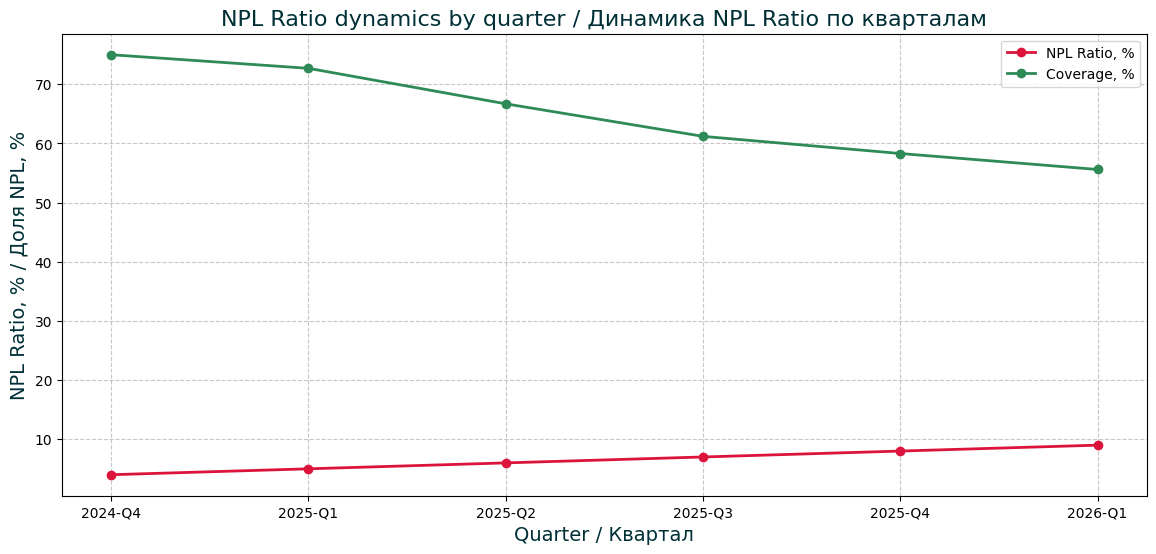

In [68]:
report_quarter = npl_df["report_quarter"]
npl_ratio_pct = npl_df["npl_ratio_pct"]
coverage_ratio_pct = npl_df["coverage_ratio_pct"]


plt.figure(figsize=(14, 6))

plt.plot(
    report_quarter,
    npl_ratio_pct,
    color='crimson',
    marker='o',
    linewidth=2,
    label="NPL Ratio, %"
)

plt.plot(
    report_quarter,
    coverage_ratio_pct,
    color="seagreen",
    marker="o",
    linewidth=2,
    label="Coverage, %"
)

plt.title("NPL Ratio dynamics by quarter / Динамика NPL Ratio по кварталам", color="#003036", fontsize=16)
plt.xlabel("Quarter / Квартал", fontsize=14, color="#003036")
plt.ylabel("NPL Ratio, % / Доля NPL, %", fontsize=14, color="#003036")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig("../docs/2_npl_ratio_by_quarters.png")

plt.show()